## Bibliotecas necessárias para a análise:
scipy, CubicSpline do Scipy, Pandas, Numpy, Matplotlib e Seaborn

In [1]:
import scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

## Importação e tratamento inicial do arquivo de dados:
Passagem dos dados referentes a datas para o formato correto, separação das horas dos dias em uma 
coluna separada e transformação de dos valores NaN para formato numérico, preenchendo com zeros

In [2]:
df = pd.read_csv("Projeto_trafico/Metro_Interstate_Traffic_Volume.csv")
#df = df.fillna(0) #coloca 0 quando encontra NaN
df['date_time'] = pd.to_datetime(df['date_time'])
df['hora'] = df['date_time'].dt.hour
df['dia'] = df['date_time'].dt.day_of_week
df['mes'] = df['date_time'].dt.month
df['ano'] = df['date_time'].dt.year
df['data'] = df['date_time'].dt.date
print(df)

      holiday    temp  rain_1h  snow_1h  clouds_all  weather_main  \
0         NaN  288.28      0.0      0.0          40        Clouds   
1         NaN  289.36      0.0      0.0          75        Clouds   
2         NaN  289.58      0.0      0.0          90        Clouds   
3         NaN  290.13      0.0      0.0          90        Clouds   
4         NaN  291.14      0.0      0.0          75        Clouds   
...       ...     ...      ...      ...         ...           ...   
48199     NaN  283.45      0.0      0.0          75        Clouds   
48200     NaN  282.76      0.0      0.0          90        Clouds   
48201     NaN  282.73      0.0      0.0          90  Thunderstorm   
48202     NaN  282.09      0.0      0.0          90        Clouds   
48203     NaN  282.12      0.0      0.0          90        Clouds   

          weather_description           date_time  traffic_volume  hora  dia  \
0            scattered clouds 2012-10-02 09:00:00            5545     9    1   
1          

## Primeira análise (Apenas um exemplo, não fazer dessa forma): 
### Número de carros por condição metereológica

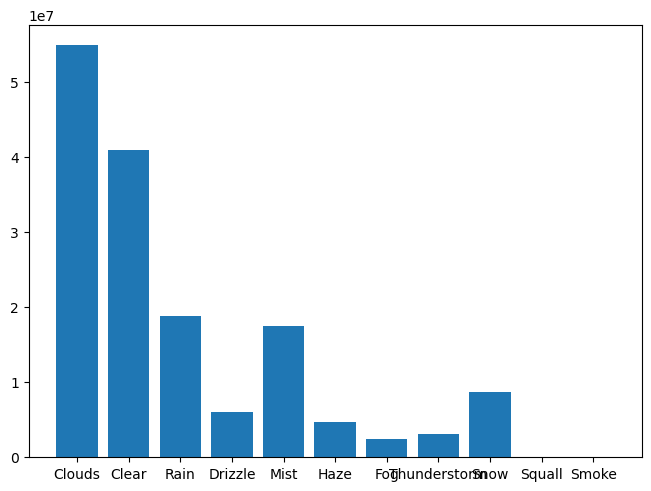

In [3]:
### FORMA NUMERO 1 DE TRAZER A ESTATISTICA NUMERO DE VEICULOS X CONDIÇÃO CLIMATICA ###

climas = [df[df['weather_main']==n] for n in df['weather_main'].unique()] #unique() faz uma lista dos valores unicos

soma_cada_clima = [n['traffic_volume'].sum() for n in climas]

fig = plt.subplots(layout='constrained')
plt.bar(df['weather_main'].unique(), soma_cada_clima)
plt.show()


# Forma certa de fazer a análise acima:

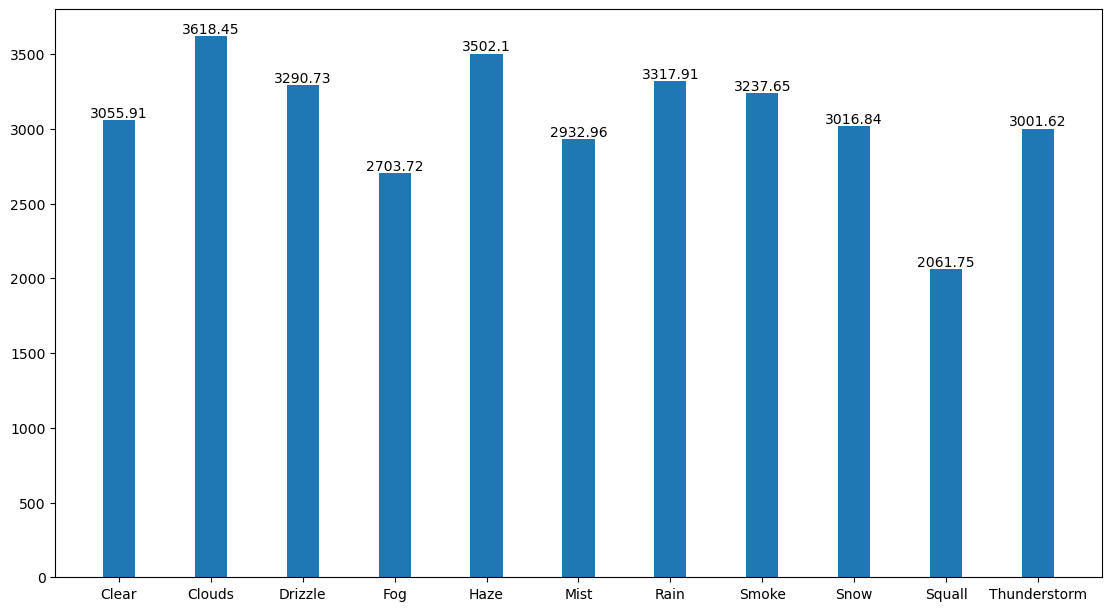

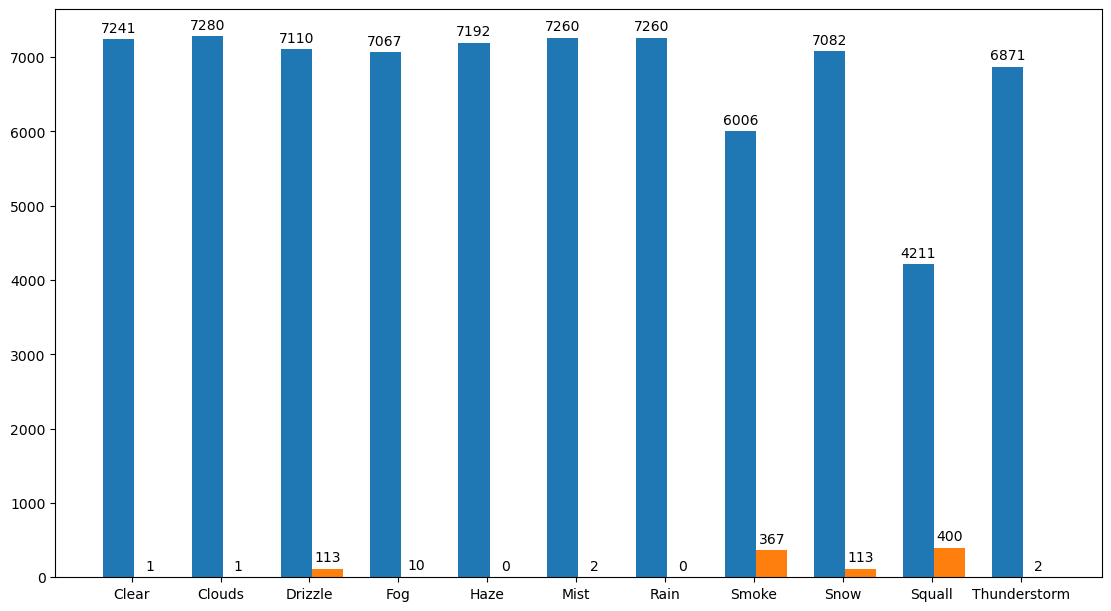

In [4]:
### FORMA NUMERO 2 DE TRAZER A ESTATISTICA NUMERO DE VEICULOS X CONDIÇÃO CLIMATICA (MELHOR)###

veiculos_clima = df.groupby('weather_main')['traffic_volume'].agg(['mean','sum','max','min']) #groupby funciona como no SQL, e .agg agrega uma série de operações possiveis
width = 0.35
fig, ax = plt.subplots(figsize = (11,6), layout='constrained')
media = ax.bar(veiculos_clima.index,veiculos_clima['mean'], width,label = veiculos_clima['mean'])
ax.bar_label(media)
plt.show()

fig, ax = plt.subplots(figsize = (11,6), layout='constrained')
operacoes = ['max','min']
width = 0.35
multiplier = 0
x = np.arange(len(veiculos_clima.index)) 
for i in operacoes:
    offset = width*multiplier
    grafico = ax.bar(x+offset, veiculos_clima[i],width, label=i)
    ax.bar_label(grafico, padding=3)
    multiplier +=1
ax.set_xticks(x + width-0.2, veiculos_clima.index)
plt.show()

### Os gráficos acima mostram a média de trânsito e os valores máximos e mínimos em cada condição meteorológica
Nota-se uma diminuição da média de trânsito de cerca de 19% em dias com neblina, 38% para vendavais e 12% para nevoeiro, todos em comparação
com a média de dias nublados e ensolarados
Entende-se, portanto, uma clara diminuição do fluxo de pessoas nestas condições adversas

O segundo gráfico revela que, apesar de uma menor média em dias de neblina, vendavais e nevoeiro, os valores que mais se sobressaem no trânsito máximo foram de fumaça e vendaval. Isso pode mostrar que a condição de fumaça pode assustar mais motoristas a depender do nível de fumaça do dia, apesar da média ser comparável a dias de ensolarados. A condição de forte vento (squall) é a condição meteorológica mais evitada, com a menor média, e a menor quantidade máxima de veículos

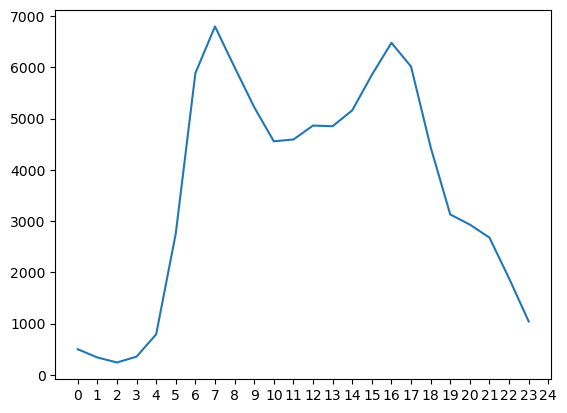

In [5]:
### TENTATIVA NUMERO 2: evolução do trafego por hora ###

df_um_dia = df[df['date_time'].dt.date == pd.to_datetime('2014-05-05').date()]

tick = np.linspace(0,24,25)

plt.plot(df_um_dia['hora'],df_um_dia['traffic_volume'])
plt.xticks(tick)
plt.show()

## Evolução por hora do tráfego
O gráfico acima representa a evolução por hora do trânsito para um dia específico, mostrando que a maior quantidade de tráfego se dá entre as
6 e 7 horas, dado pelo começo do horário comercial, e entre 16 e 17 horas, marcado pelo fim deste. 
Apesar disso, é mais válido olhar para a média do tráfego, feito abaixo

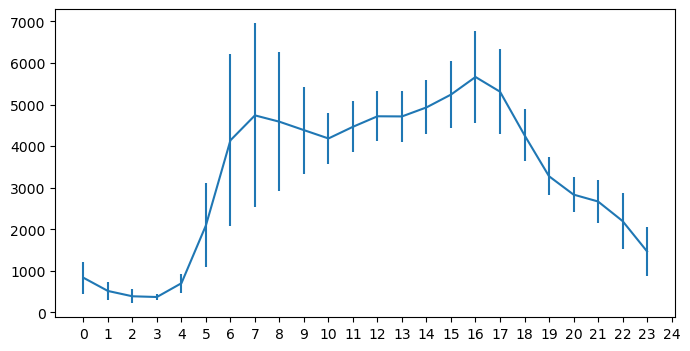

In [6]:
### TENTATIVA 3: FAZER A MEDIA PARA TODOS OS DIAS DA EVOLUÇÃO DO TRAFEGO POR HORA ###

df_media = df.groupby(df['date_time'].dt.hour)['traffic_volume'].agg(['mean','std'])
fig = plt.subplots(figsize=(8,4))
plt.errorbar(df_media.index, df_media['mean'],df_media['std'])
plt.xticks(tick)
plt.show()

## Evolução por hora do tráfego médio de todos os dias
O gráfico acima representa a evolução média por hora do trânsito, onde as barras verticais indicam o desvio padrão dos dados.
De fato, entre 6 e 7 horas temos o primeiro pico de trânsito, porém, este também é o horário com a maior dispersão de dados, algo não observado
entre 00:00 - 04:00 ou 09:00 - 14:00. Isso significa que o trânsito é altamente variado nesses horários, com picos de tráfego podendo ocorrer por
conta de acidentes, e os menores valores sendo referentes a feriados, por exemplo. 
O momento de maior trânsito se dá no fechamento do horário comercial, entre 16:00 e 17:00, porém com uma dispersão menor dos dados em comparação com o pico
da parte da manhã

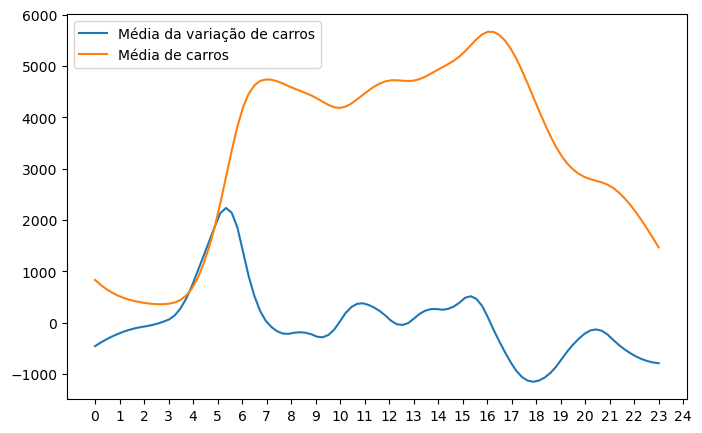

In [7]:
### DERIVADA DA EVOLUÇÃO EM FUNÇÃO DA HORA (AUMENTO DO FLUXO DE CARROS) ###

df_media = df.groupby(df['date_time'].dt.hour, as_index=False)['traffic_volume'].agg(['mean','std'])
interpolacao = CubicSpline(df_media['date_time'],df_media['mean'])
derivada = interpolacao.derivative()
x = np.linspace(0,23,100)
fig = plt.subplots(figsize=(8,5))
plt.plot(x,derivada(x),label='Média da variação de carros')
plt.plot(x,interpolacao(x),label='Média de carros')
plt.legend(loc='upper left')
plt.xticks(tick)
plt.show()

## Média da variação do fluxo de carros por hora, em comparação com a média de carros por hora
O gráfico acima explora como ocorre o aumento ou diminuição do número de carros na rodovia em função do horário.
Como exemplo, apesar do trânsito ter seu pico no horário da manhã entre 6 e 7 horas, a maior variação do número de carros se dá antes, às 5 horas da manhã
Isto exibe que o aumento do número de carros acontece de forma súbita, o que pode indicar maior congestionamento às 5 horas da manhã nas vias que levam à 
rodovia analisada. A partir das 7 da manhã, a quantidade de carros se estabiliza, sinalizado pela função em azul próximo à 0 no gráfico acima. Após as 16 horas, a variação de carros é negativa, isto é, mais carros estão saindo da rodovia do que entrando nela, sinalizando um possível engarrafamento nas vias das cidades relacionadas à rodovia.

5    21.539586
Name: mean, dtype: float64 6    32.997596
Name: mean, dtype: float64


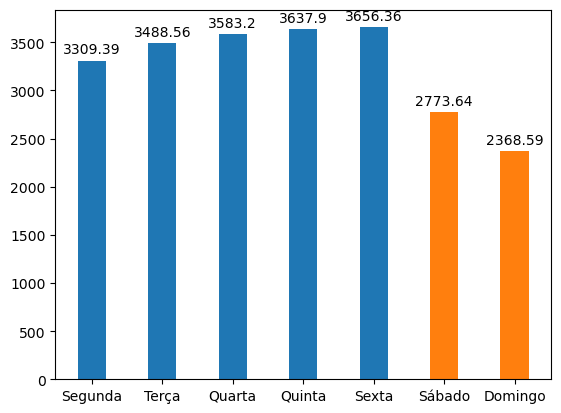

In [8]:
### 4 PROPOSTA: TRANSITO DIA DE SEMANA X FIM DE SEMANA ###
# Dia 02-10-2012 é uma terça-feira -> dia 1

df_dias = df.groupby(df['dia'],as_index=False)['traffic_volume'].agg(['sum','mean'])
df_semana = df_dias.iloc[:5]
df_fim_semana = df_dias.iloc[5:7]   
posicao = np.linspace(0,6,7)
fig, ax = plt.subplots()
grafico1 = ax.bar(df_semana['dia'], df_semana['mean'],0.4,label=df_semana['mean'])
ax.bar_label(grafico1, padding=3)
grafico2 = ax.bar(df_fim_semana['dia'], df_fim_semana['mean'],0.4,label=df_fim_semana['mean'])
ax.bar_label(grafico2, padding=3)

media_semana = df_semana['mean'].mean()
porc_sabado = 100 - df_fim_semana[df_fim_semana['dia']==5]['mean']*100/media_semana
porc_domingo = 100 - df_fim_semana[df_fim_semana['dia']==6]['mean']*100/media_semana
print(porc_sabado, porc_domingo)
ax.set_xticks(posicao, ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado', 'Domingo'])
plt.show()

## Comparação entre a média de trânsito em dias de semana x fins de semana
O gráfico mostra uma clara tendência de redução do trânsito médio em fins de semana, 
sendo, respectivamente, de 21,5% e 32,9% para sábado e domingo, em comparação com a média dos dias de semana

5    21.539586
Name: mean, dtype: float64 6    32.997596
Name: mean, dtype: float64


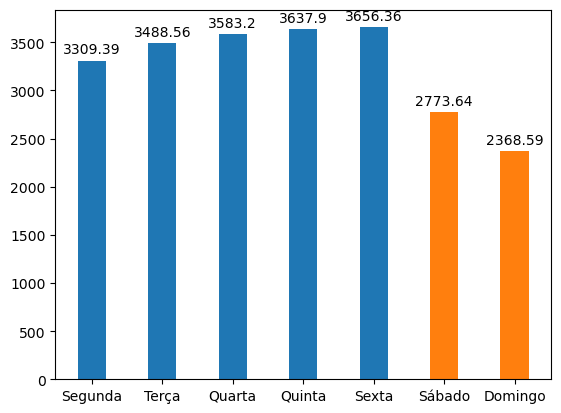

In [9]:
### Outra forma de fazer isso ###

df_dias = df.groupby(df['dia'],as_index=False)['traffic_volume'].agg(['sum','mean'])
df_dia_semana = df_dias[df_dias['dia']< 5]
df_fim_semana = df_dias[df_dias['dia']>=5]
posicao = np.linspace(0,6,7)
fig, ax = plt.subplots()
grafico1 = ax.bar(df_dia_semana['dia'], df_dia_semana['mean'],0.4,label=df_semana['mean'])
ax.bar_label(grafico1, padding=3)
grafico2 = ax.bar(df_fim_semana['dia'], df_fim_semana['mean'],0.4,label=df_fim_semana['mean'])
ax.bar_label(grafico2, padding=3)

media_semana = df_semana['mean'].mean()
porc_sabado = 100 - df_fim_semana[df_fim_semana['dia']==5]['mean']*100/media_semana
porc_domingo = 100 - df_fim_semana[df_fim_semana['dia']==6]['mean']*100/media_semana
print(porc_sabado, porc_domingo)
ax.set_xticks(posicao, ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado', 'Domingo'])
plt.show()

O mesmo gráfico anterior, porém feito de outra forma (sem a utilização de 'pd.iloc')

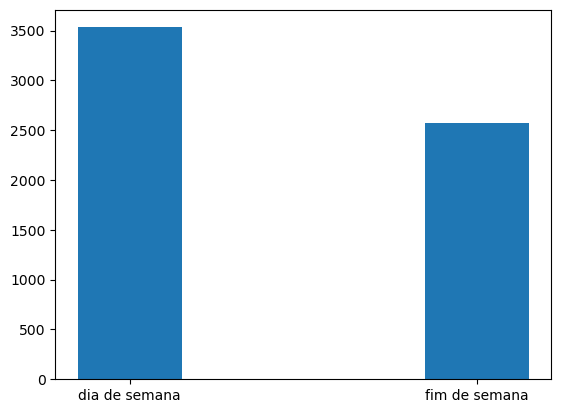

In [10]:
### SEPARAR EM DIA DE SEMANA / FIM DE SEMANA ###

df_separacao = df.copy(deep=True) # Mudanças em df_separacao nao afetam df
df_separacao['tipo de dia'] = np.where(df['dia']<5, 'dia de semana','fim de semana')
df_dias = df_separacao.groupby('tipo de dia', as_index=False)['traffic_volume'].mean()

plt.bar(df_dias['tipo de dia'],df_dias['traffic_volume'], 0.3)
plt.show()

## Exemplo de utilização da função np.where() Para fazer a separação entre dias de semana e fins de semana de forma 

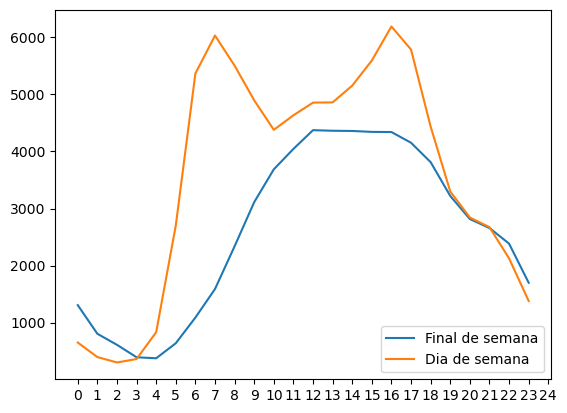

In [11]:
### EVOLUÇÃO DIARIA DO TRANSITO FIM DE SEMANA X DIA DE SEMANA ###

df_separacao = df.copy(deep=True) # Mudanças em df_separacao nao afetam df
df_separacao['tipo de dia'] = np.where(df['dia']<5, 'dia de semana','fim de semana')
df_por_hora = df_separacao.groupby(['tipo de dia','hora'],as_index=False)['traffic_volume'].mean()
df_final_semana = df_por_hora[df_por_hora['tipo de dia']=='fim de semana']
df_dia_semana = df_por_hora[df_por_hora['tipo de dia']=='dia de semana']

plt.plot(df_final_semana['hora'],df_final_semana['traffic_volume'],label = 'Final de semana')
plt.plot(df_final_semana['hora'],df_dia_semana['traffic_volume'],label='Dia de semana')
plt.legend()
plt.xticks(tick)
plt.show()

## Evolução média do trânsito em função do horário para diferentes dias
Nota-se uma diferença grande entre a evolução do trânsito em fins de semana em comparação com dias de semana.
Primeiramente não há picos de trânsito, como nos dias comerciais, o que reflete a menor média de transito total aos fins de semana.
Também ocorre um aumento do trânsito mais tarde aos fins de semana, com esse aumento se dando de forma mais suave, diminuindo a probabilidade de
engarrafamentos aos fins de semana. A maior quantidade de veículos se dá entre 11:00 e 16:00, sendo estável nesse período, o que pode mostrar
a diferença de horários escolhidos para viajar nestes dias. 
Por fim, nota-se que, na maioria dos horários, o trânsito dia de semana é maior, menos nos períodos $t>21h$, $t<3h$, o que corresponde a preferência por ficar até horários mais tardes em outras cidades aos fins de semana

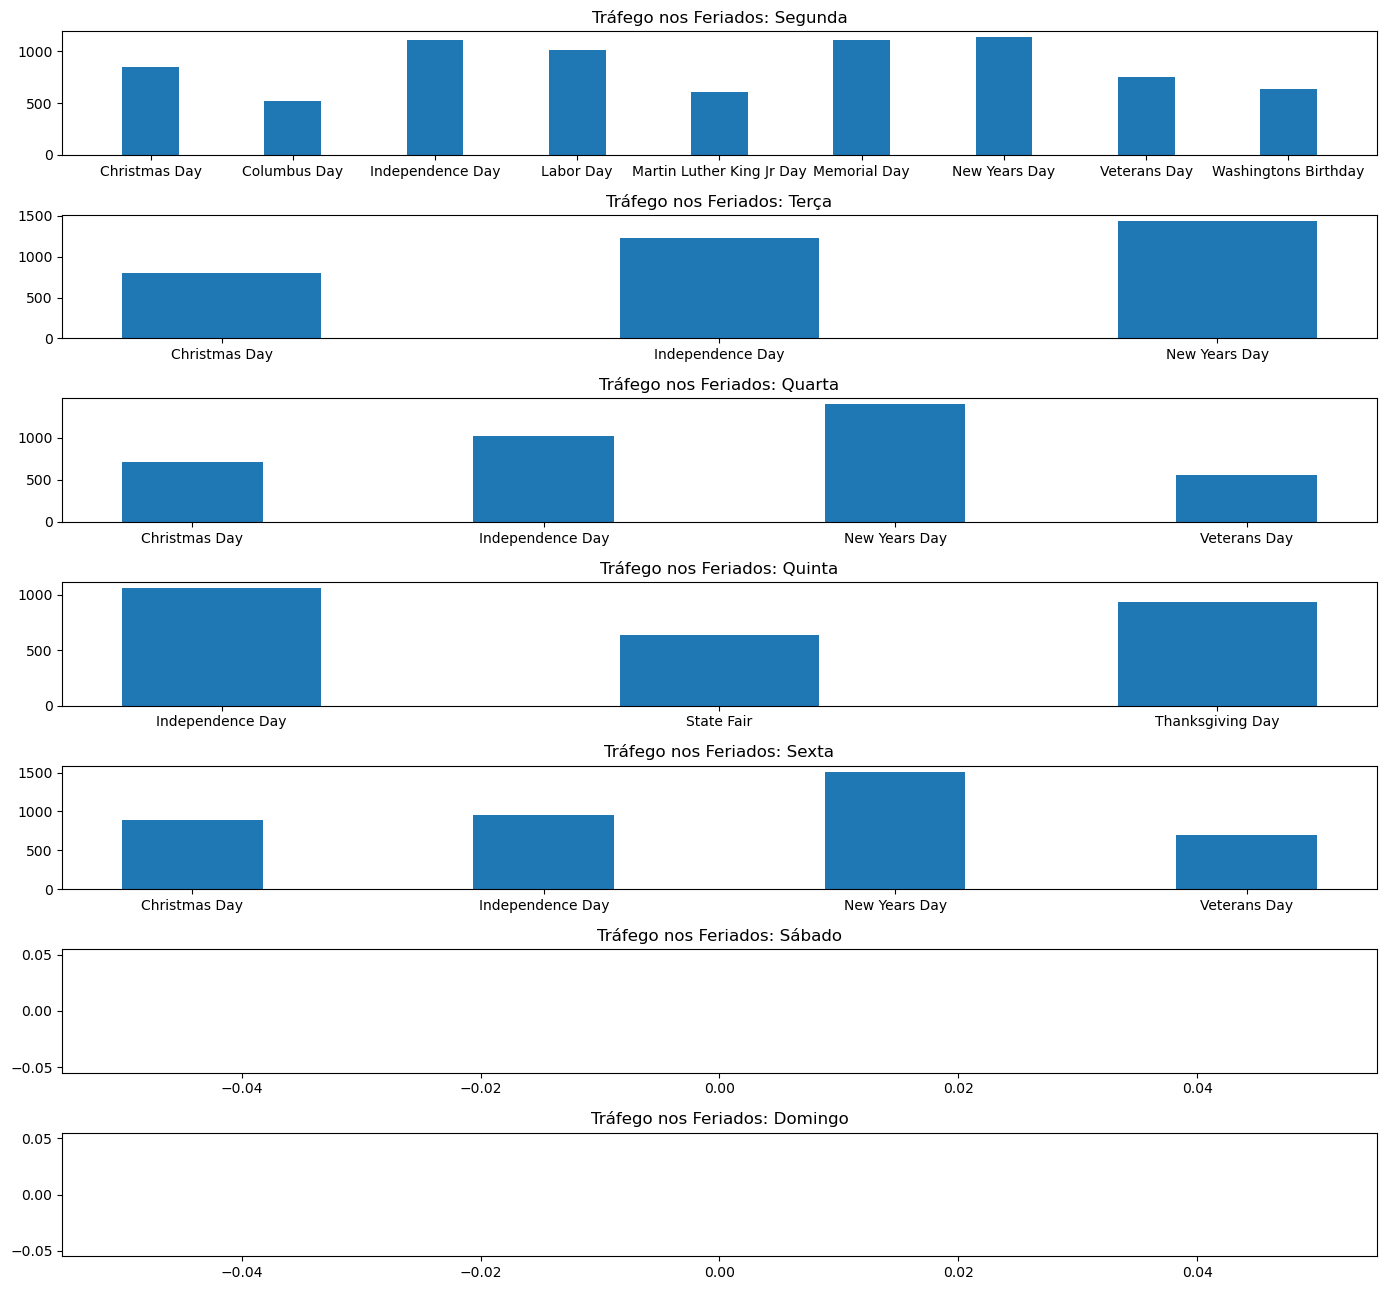

In [12]:
### Comparação entre transito nos feriados e dias normais (o mesmo dia da semana) ###

feriado = df.groupby(['holiday','dia'],as_index=False)['traffic_volume'].agg(['mean','count'])
feriado.loc[feriado['holiday']==0, 'holiday'] = 'No holiday'
dias_nomes = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(14, 13))
for i, ax in enumerate(axes):
    feriados_dias = feriado[feriado['dia']==i]
    if(len(feriados_dias['holiday'].unique())==1):
        pass
    else:
        ax.bar(feriados_dias['holiday'],feriados_dias['mean'],0.4)
        ax.set_title(f'Tráfego nos Feriados: {dias_nomes[i]}')

plt.tight_layout() # Ajusta o espaçamento para não ficar um por cima do outro
plt.show()

## Tráfego nos feriados em função do dia da semana do feriado
Os gráficos acima mostram a distribuição do trânsito em cada feriado por dia de semana. Com esses dados, é possível perceber os principais feriados
onde as pessoas viajam, e se há preferencia por feriados em determinados dias da semana

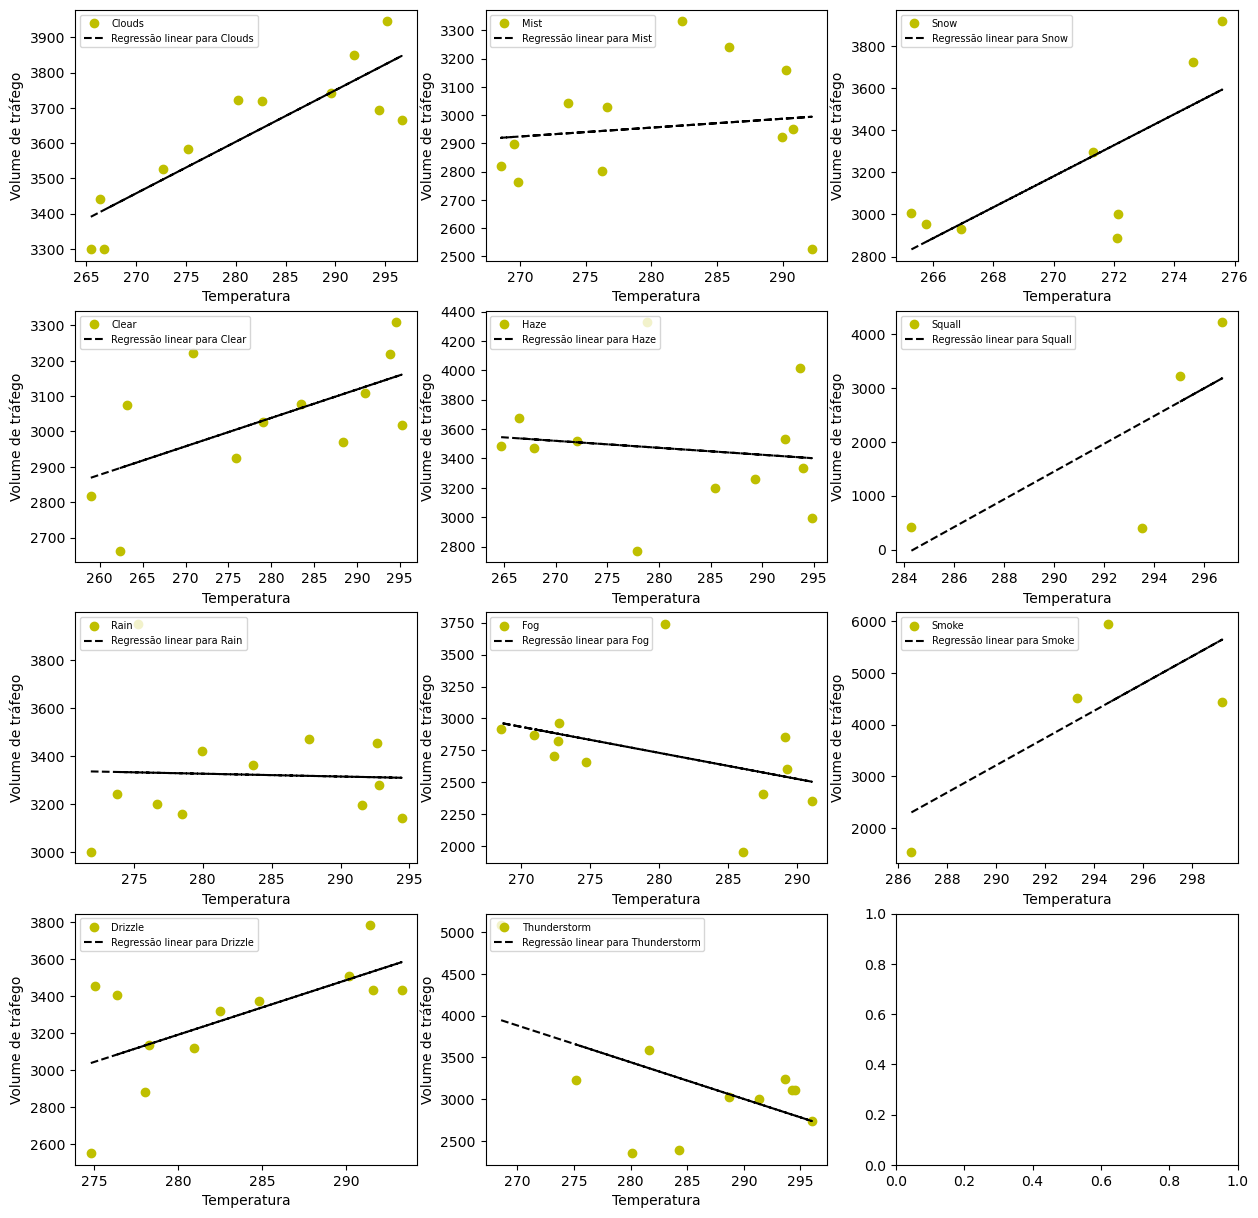

In [13]:
### CORRELAÇÃO ENTRE AS VARIAVEIS ###

correlacao = df.corr(method='pearson', min_periods=1, numeric_only=True) #coeficientes de correlação entre todas as variaveis numéricas

#Correlação entre temperatura e trânsito, dado pela média mensal
correlacao_temperatura = df.copy(deep=True)
climas = df['weather_main'].unique()
fig, ax = plt.subplots(4,3, figsize=(15,15))
a=0
b=0
for clima in climas:
    correlacao_temperatura1 = correlacao_temperatura[correlacao_temperatura['weather_main']==clima]
    correlacao_temperatura2 = correlacao_temperatura1[correlacao_temperatura1['temp']>100]
    media = correlacao_temperatura2.groupby('mes',as_index = False)[['temp','traffic_volume']].mean()
    coef = np.polyfit(media['temp'],media['traffic_volume'],1)
    poly1d_fn = np.poly1d(coef) 
# poly1d_fn is now a function which takes in x and returns an estimate for y
    ax[a,b].plot(media['temp'],media['traffic_volume'],'yo', label=f'{clima}')
    ax[a,b].plot(media['temp'], poly1d_fn(media['temp']), '--k', label=f'Regressão linear para {clima}')
    ax[a,b].legend(loc='upper left',fontsize=7)
    ax[a,b].set_xlabel('Temperatura')
    ax[a,b].set_ylabel('Volume de tráfego')
    if a<3:
        a+=1
    else:
        b+=1
        a=0
plt.show()

## Correlação entre a temperatura e eo volume de tráfego para diferentes condições metereológicas
A correlação entre as variáveis citadas se dão maiores em determinados climas, como, por exemplo, os climas com neve e núvens.
Outro climas, entretanto, mostram uma correlação muito pequena, como chuva e dias ensolarados. 
As médias (pontos amarelos) foram tirados mensalmente

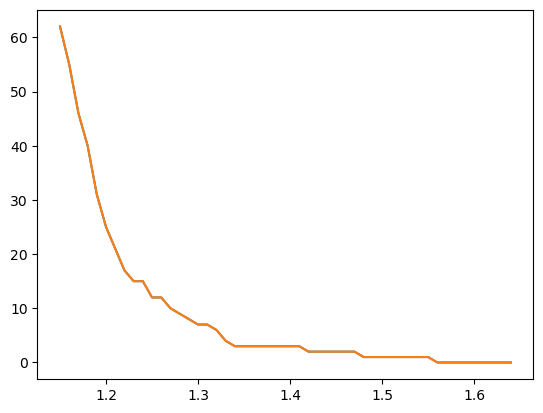

         temp weather_main           date_time  traffic_volume
9636   274.65       Clouds 2013-10-24 09:00:00            5487
9637   278.48       Clouds 2013-10-24 14:00:00            5741
9638   278.48       Clouds 2013-10-24 16:00:00            7094
9639   278.15       Clouds 2013-10-24 17:00:00            6735
9640   276.80       Clouds 2013-10-24 20:00:00            3457
9641   276.39       Clouds 2013-10-24 23:00:00            1400
15138  290.95         Mist 2014-06-23 06:00:00            5477
15139  290.95          Fog 2014-06-23 06:00:00            5477
15140  292.08         Mist 2014-06-23 07:00:00            6405
15141  292.08          Fog 2014-06-23 07:00:00            6405
15142  297.57        Clear 2014-06-23 10:00:00            4447
15143  299.52        Clear 2014-06-23 12:00:00            4724
15211  289.95       Clouds 2014-07-03 08:00:00            5346
15212  293.90        Clear 2014-07-03 10:00:00            4715
15213  296.14       Clouds 2014-07-03 13:00:00         

In [14]:
### DIAS QUE FOGEM CONSIDERAVELMENTE DA MÉDIA DE TRANSITO ###

#Gráfico de quantidade de dias em função da porcentagem de transito a mais do que a média para dias de semana
media_todos = df.groupby('dia', as_index=False)['traffic_volume'].mean()
media_semana = media_todos[media_todos['dia']<5]
media_final = media_semana['traffic_volume'].mean()

valores = df.groupby(['data'],as_index=False)['traffic_volume'].mean()

quantidade=[]
x = []
porcentagem = 1.15
for _ in range(50):
    quantidade.append(valores[valores['traffic_volume']>media_final*porcentagem].count())
    x.append(porcentagem)
    porcentagem += 0.01
plt.plot(x, quantidade)
plt.show()

# Evolução do dia em que o transito foi 40% maior do que a média (possível acidente ou condição metereologica adversa)
casos_quarenta = valores[valores['traffic_volume']>media_final*1.4]
informacoes = df[df['data'].isin(casos_quarenta['data'])]
print(informacoes[['temp','weather_main','date_time','traffic_volume']])

## Dias onde a quantidade de trânsito foi maior do que a média total dos dados
O gráfico acima mostra a quantidade de dias onde o trânsito total do dia foi maior do que a média total dos dias.
No eixo x tempos a % maior (1.2 = 20% maior), e no eixo y a quantidade de dias onde essa porcentagem aconteceu.
Como o esperado, os dados apresentam certa dispersão, porém que ficam em volta, principalmente, de até 25% a mais de trânsito 
em comparação com a média. Os casos onde o trânsito é maior que 25% da média podem indicar problemas na estrada, acidentes ou
condições meteorológicas extremas. Destes, a tabela acima mostra a evolução dos três dias onde o trânsito foi 40% maior do que 
a média.